In [1]:
import pandas as pd
from utilities.backtest.data_manager import DataManager
from utilities.backtest.backtest_analysis import BacktestAnalysis
from strategies.backtest import backtest

In [2]:
data = DataManager(name="bybit")  # "binanceusdm"

In [ ]:
symbol = "SOL/USDT:USDT"
ohlcv = data.load(symbol, timeframe="3m", start_date="2023-12-03 00:00:00", end_date="2024-12-03 0:00:00")
# ohlcv_real_time = data.load(symbol, timeframe="3s", start_date="2023-12-02 00:00:00", end_date="2023-12-28 00:06:00")
strategy_params = {
    'average_type': 'SMA', 
    'envelopes': [0.07],
    'position_size_percentage': 100,
    # Custom parameters
    'bollinger_band_period': 14,
    'bollinger_band_deviation': 1.5,
    'rsi_period': 5,
    'rsi_overbought_level': 70,
    'rsi_oversold_level': 30,
    'atr_period': 10,
    'stop_loss_multiplier': 0.5,
    'kvo_slow': 34,
    'kvo_fast': 21,
    'kvo_signal': 9,
    # 'moving_average_period': 50,
    'initial_balance': 1000000,
    'leverage': 100,
    'stoch_rsi_period': 14,
    'stoch_rsi_rsi_period': 14,
    'stoch_rsi_k': 3,
    'stoch_rsi_d': 3
}


strategy = backtest.Backtest(strategy_params, ohlcv)
strategy.run_backtest(open_fee_rate=0.00055, close_fee_rate=0.00055)

e:\Feenix\project\TradingBot\wallet1\trading_bot_wallet1\code\strategies\strategy.py:17: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  self.data['rsi'].fillna(0, inplace=True)


In [4]:
strategy.data

strategy.data.to_csv("indicators.csv", header=True, index=True)
    

In [5]:
results = BacktestAnalysis(strategy)
results.print_metrics()
path = "..."
results.print_metrics(path)

--- General ---
Period: [2023-12-03 00:00:00] -> [2024-12-03 00:00:00]
Initial balance: 1000000.0 $
Final balance: 997276.1 $
Performance: -0.27 %
Hodl performance: 254.1%
Performance/Hodl: -71.84 %
Total trades: 11511
Time in position: 39.03 %

--- Health ---
Win rate: 46.73 %
Max drawdown at trade close: -0.27 %
Max drawdown at equity update: -0.27 %
Profit factor: 0.78
Return over max drawdown: -1.0
Sharpe ratio: -10.08
Sortino ratio: -13.78
Calmar ratio: -1.0

--- Trades ---
Average net PnL: -4.73 %
Average trades per day: 31.365
Average trades duration: 0 days 00:17:52.118842845
Best trade: +574.12 % entered 2024-08-05 13:30:00 exited 2024-08-05 13:48:00
Worst trade: -417.81 % entered 2024-04-13 22:45:00 exited 2024-04-13 22:51:00
Total winning trades: 5379
Total loosing trades: 6132
Average net PnL winning trades: 36.49 %
Average net PnL loosing trades: -40.89 %
Mean winning trades duration: 0 days 00:21:57.255995538
Mean loosing trades duration: 0 days 00:14:17.084148727
Max win

In [6]:
strategy.trades_info
path = symbol.replace('/', '-').replace(':', '-') 
strategy.save_trades_info(path)

In [7]:

strategy.equity_record
strategy.save_equity_record(path)

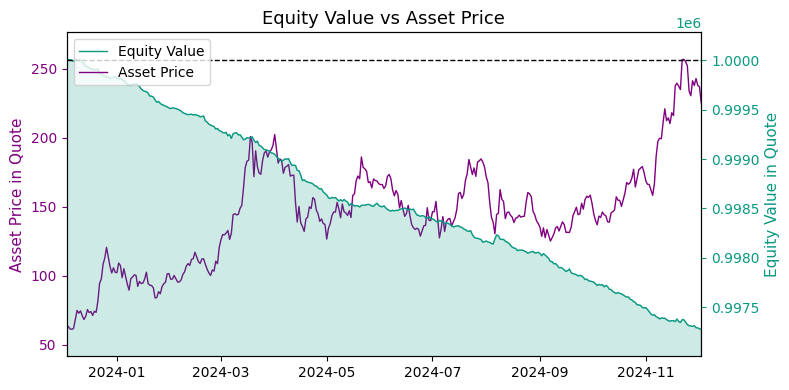

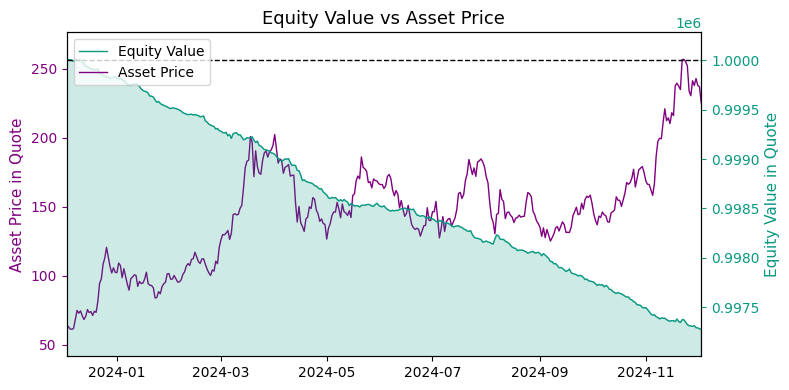

In [8]:
results.plot_equity()
results.plot_equity(path)

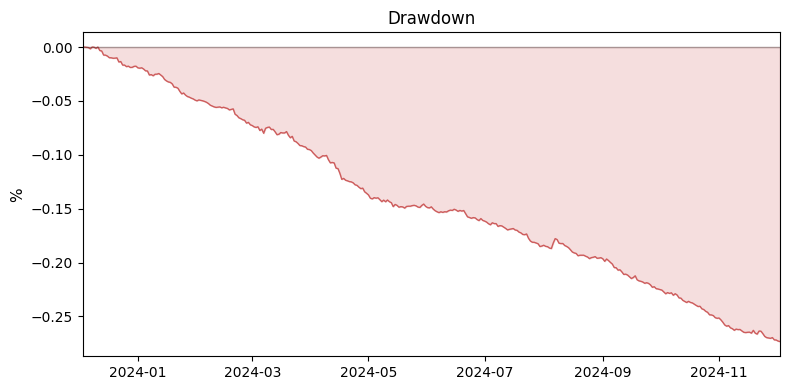

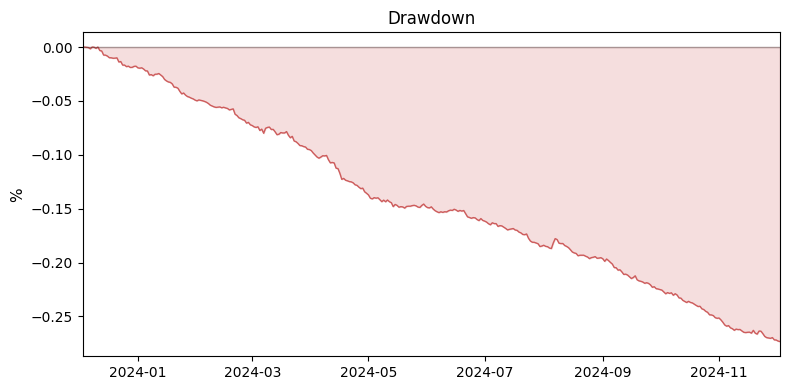

In [9]:
results.plot_drawdown()
results.plot_drawdown(path)

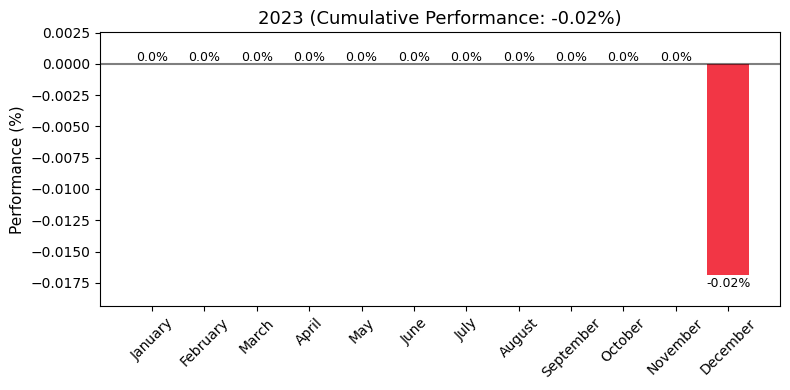

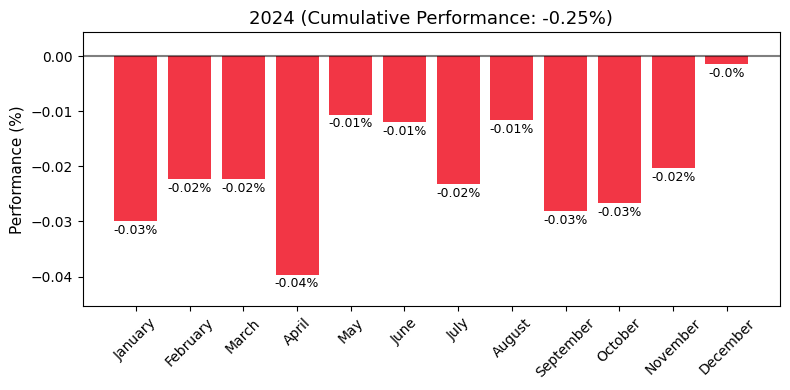

In [10]:
results.plot_monthly_performance(year="all")
# results.plot_monthly_performance(year="all", path)

In [ ]:
indicators = {
    'average': {
        'color': "white",
        'df': pd.DataFrame({
            'time': strategy.data.index,
            'average': strategy.data['average'],
        }).dropna()        
    } 
}

for i, e in enumerate(strategy_params['envelopes']):
    indicators.update({
        f'band_high_{i+1}' : {
            'color': "red",
            'df': pd.DataFrame({
                'time': strategy.data.index,
                f'band_high_{i+1}': strategy.data[f'bollinger_band_high_{i+1}'],
            }).dropna()   
        },
        f'band_low_{i+1}' : {
            'color': "green",
            'df': pd.DataFrame({
                'time': strategy.data.index,
                f'band_low_{i+1}': strategy.data[f'bollinger_band_low_{i+1}'],
            }).dropna()  
        }
        # ,
        # 'kvo': {
        #     'color': "blue",
        #     'df': pd.DataFrame({
        #         'time': strategy.data.index,
        #         f'kvo': strategy.data[f'kvo'] + 2400,
        #     }).dropna()  
        # }
        #  ,
        # 'kvo_signal': {
        #     'color': "blue",
        #     'df': pd.DataFrame({
        #         'time': strategy.data.index,
        #         f'kvo_signal': strategy.data[f'kvo_signal'] + 2400,
        #     }).dropna()  
        # }

    })

results.plot_candlestick(indicators=indicators)